In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import os
import pandas as pd
import matplotlib.ticker as ticker

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

#plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'Phase 2', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [4]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [5]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [6]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [7]:
regionGroups = {
    'BRA' : ['Brazil'],
    'CAN' : ['Canada'],
    'CEU' : ['Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Cyprus', 'Czechia', 'Estonia', 'Croatia', 'Hungary', 'Lithuania',
             'Latvia', 'North Macedonia', 'Poland', 'Romania', 'Republic of Serbia', 'Slovenia', 'Slovakia', 'Kosovo', 'Northern Cyprus'],
    'CHN' : ['China', 'Mongolia', 'Taiwan'],
    'EAF' : ['Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Mauritius', 'Rwanda', 'Sudan', 'South Sudan', 'Somalia', 'Burundi', 'Djibouti',
             'Somaliland'],
    'INDIA' : ['India'],
    'INDO' : ['Indonesia', 'Papua New Guinea'],
    'JPN' : ['Japan'],
    'KOR' : ['North Korea', 'South Korea'],
    'ME' : ['United Arab Emirates', 'Bahrain', 'Israel', 'Iraq', 'Iran', 'Jordan', 'Kuwait', 'Lebanon', 'Montenegro', 'Saudi Arabia',
            'Oman', 'Yemen', 'Syria', 'Qatar', 'Palestine'],
    'MEX' : ['Mexico'],
    'NAF' : ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Tunisia', 'Western Sahara'],
    'OCE' : ['Australia', 'New Zealand', 'Fiji', 'Vanuatu', 'New Caledonia', 'Solomon Islands'],
    'RCAM' : ['Costa Rica', 'Cuba', 'Curaçao', 'Dominican Republic', 'Guatemala', 'Honduras', 'Haiti', 'Jamaica', 'Nicaragua',
             'El Salvador', 'Trinidad and Tobago', 'The Bahamas', 'Puerto Rico', 'Panama', 'Belize'],
    'RSAF' : ['Angola', 'Botswana', 'Mozambique', 'Namibia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'eSwatini', 'Lesotho', 'Uganda'],
    'RSAM' : ['Argentina', 'Falkland Is.', 'Bolivia', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Paraguay', 'Uruguay', 'Venezuela',
             'Guyana', 'Suriname'],
    'RSAS' : ['Bangladesh', 'Sri Lanka', 'Nepal', 'Pakistan', 'Bhutan', 'Afghanistan'],
    'RUS' : ['Armenia', 'Azerbaijan', 'Georgia', 'Russia'],
    'SAF' : ['South Africa'],
    'SEAS' : ['Brunei', 'Cambodia', 'Myanmar', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam', 'Laos'],
    'STAN' : ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'TUR' : ['Turkey'],
    'UKR' : ['Belarus', 'Moldova', 'Ukraine'],
    'USA' : ['United States of America'],
    'WAF' : ['Benin', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Ivory Coast', 'Cameroon', 'Gabon', 'Gambia', 'Ghana', 'Niger', 'Nigeria',
             'Senegal', 'Togo', 'Mauritania', 'Mali', 'Burkina Faso', 'Chad', 'Central African Republic', 'Guinea-Bissau', 'Guinea',
             'Sierra Leone', 'Liberia', 'Equatorial Guinea'],
    'WEU' : ['Austria', 'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Gibraltar',
             'Greece', 'Ireland', 'Iceland', 'Italy', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Portugal', 'Sweden'],
}

In [8]:
newLocations = {'BR' : 'BRA',
                'CA' : 'CAN',
                'PL' : 'CEU',
                'CN' : 'CHN',
                'ET' : 'EAF',
                'IN' : 'INDIA',
                'ID' : 'INDO',
                'JP' : 'JPN',
                'KR' : 'KOR',
                'IR' : 'ME',
                'MX' : 'MEX',
                'EG' : 'NAF',
                'AU' : 'OCE',
                'GT' : 'RCAM',
                'BW' : 'RSAF',
                'CL' : 'RSAM',
                'PK' : 'RSAS',
                'RU' : 'RUS',
                'ZA' : 'SAF',
                'PH' : 'SEAS',
                'UZ' : 'STAN',
                'TR' : 'TUR',
                'UA' : 'UKR',
                'US' : 'USA',
                'NG' : 'WAF',
                'RER' : 'WEU'}

In [9]:
def find_key_by_value(dictionary, value):
    for key, val in dictionary.items():
        if key == value:
            return key
    return None

In [10]:
for key, value in newLocations.items():
    hydrogenGWPDF['Location'] = hydrogenGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ammoniaGWPDF['Location'] = ammoniaGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    methanolGWPDF['Location'] = methanolGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ethyleneGWPDF['Location'] = ethyleneGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))

In [11]:
# Define a custom color map from white to a specific color
colors = ['#D8D8D8', '#000000']  
cmapName = 'fossilColorMap'
customFossilMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#C5B3E5', '#52318E']  
cmapName = 'blueColorMap'
customBlueMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#FCACA6', '#B71205'] 
cmapName = 'solarColorMap'
customSolarMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#9EE1f1', '#167F99'] 
cmapName = 'windColorMap'
customWindMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

In [12]:
def plot_world_maps(type, df, cmap, title, chemical):
    
    fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[1.5], fig_height*0.4))

    world = gpd.read_file(r'/Users/abhinabera/Downloads/110m_cultural/ne_110m_admin_0_countries.shp')

    # Filter out Antarctica and Greenland
    world = world[world['SOVEREIGNT'] != 'Antarctica']
    world = world[world['ADMIN'] != 'Greenland']

    # Set up colormap and normalization based on GWP values
    vmin = df['Percent'].min()
    vmax = df['Percent'].max()
    norm = plt.Normalize(vmin, vmax)

    ax1.set_title(title, fontweight = 'bold', fontsize = fontsize_title)
    ax1.set_yticks([])

    for region, countries in regionGroups.items():
        region_data = world[world['ADMIN'].isin(countries)]
        gwpValues1 = df[df['Location'] == region]['Percent']
        color1 = cmap(norm(gwpValues1))
        region_data.plot(ax = ax1, color = color1, label = region)
    
    ax1.set_xticks([])

    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [x_position, y_position, width, height]
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')

    #cbar.ax.yaxis.set_tick_params(rotation = 90)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    #for tick_label in cbar.ax.yaxis.get_ticklabels():
    #    tick_label.set_verticalalignment('center') 
        
    path = os.path.join('..', 'Results', 'Phase 2', 'Regional global', title)
    plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Regional BAU', chemical, chemical + ' ' + type + ' ' + title + '.png')
    plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Regional BAU', chemical, chemical + ' ' + type + ' ' + title + '.svg')    
    plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
    plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

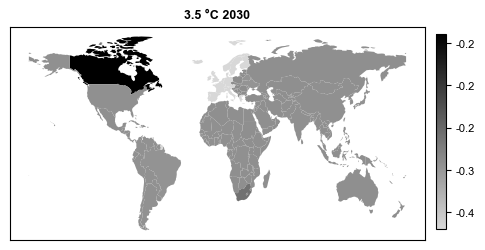

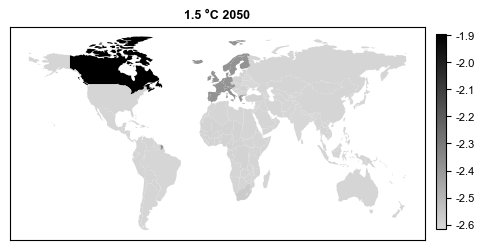

In [13]:
hydrogenFossilDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar') & ~hydrogenGWPDF['Activity'].str.contains('CCS')]
hydrogenBaseFossilDF = hydrogenFossilDF[hydrogenFossilDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenFossilDF.merge(hydrogenBaseFossilDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP62030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP62050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP192030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
hydrogenRCP192050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Fossil', hydrogenRCP62030, customFossilMap, '3.5 °C 2030', 'Hydrogen')
#plot_world_maps('', hydrogenRCP62050, customFossilMap, '3.5 °C 2050', 'Hydrogen')
#plot_world_maps('', hydrogenRCP192030, customFossilMap, '1.5 °C 2030', 'Hydrogen')
plot_world_maps('Fossil', hydrogenRCP192050, customFossilMap, '1.5 °C 2050', 'Hydrogen')

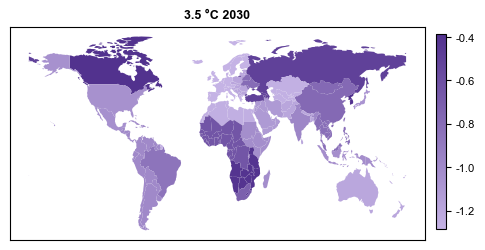

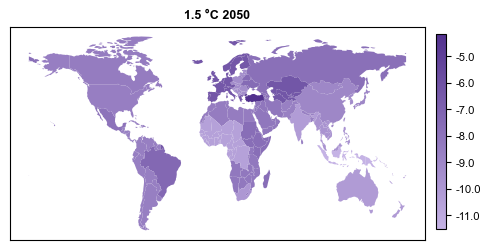

In [14]:
hydrogenBlueDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]
hydrogenBaseBlueDF = hydrogenBlueDF[hydrogenBlueDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenBlueDF.merge(hydrogenBaseBlueDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP62030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP62050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP192030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
hydrogenRCP192050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Blue', hydrogenRCP62030, customBlueMap, '3.5 °C 2030', 'Hydrogen')
#plot_world_maps('', hydrogenRCP62050, customBlueMap, '3.5 °C 2050', 'Hydrogen')
#plot_world_maps('', hydrogenRCP192030, customBlueMap, '1.5 °C 2030', 'Hydrogen')
plot_world_maps('Blue', hydrogenRCP192050, customBlueMap, '1.5 °C 2050', 'Hydrogen')

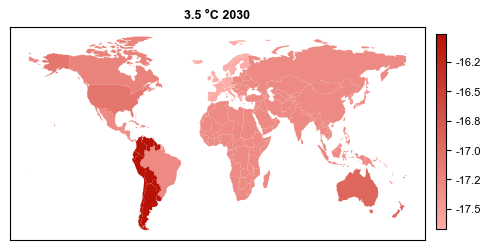

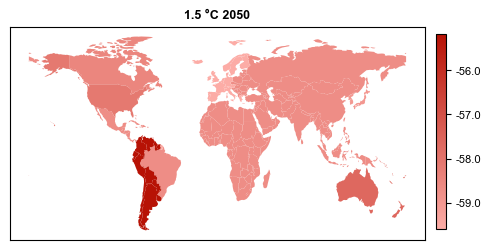

In [15]:
hydrogenSolarDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity')]
hydrogenBaseSolarDF = hydrogenSolarDF[hydrogenSolarDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenSolarDF.merge(hydrogenBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP62030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP62050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP192030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
hydrogenRCP192050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Solar', hydrogenRCP62030, customSolarMap, '3.5 °C 2030', 'Hydrogen')
#plot_world_maps('', hydrogenRCP62050, customSolarMap, '3.5 °C 2050', 'Hydrogen')
#plot_world_maps('', hydrogenRCP192030, customSolarMap, '1.5 °C 2030', 'Hydrogen')
plot_world_maps('Solar', hydrogenRCP192050, customSolarMap, '1.5 °C 2050', 'Hydrogen')

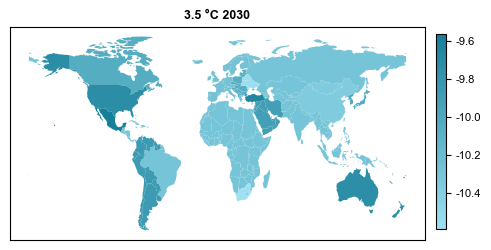

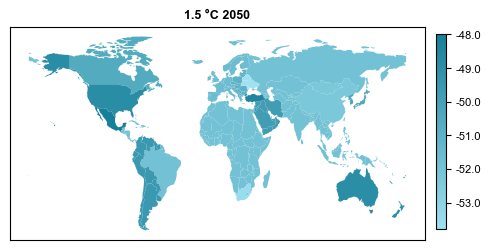

In [16]:
hydrogenWindDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity')]
hydrogenBaseWindDF = hydrogenWindDF[hydrogenWindDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenWindDF.merge(hydrogenBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP62030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP62050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP6')]
hydrogenRCP192030 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2030') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
hydrogenRCP192050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Wind', hydrogenRCP62030, customWindMap, '3.5 °C 2030', 'Hydrogen')
#plot_world_maps('', hydrogenRCP62050, customWindMap, '3.5 °C 2050', 'Hydrogen')
#plot_world_maps('', hydrogenRCP192030, customWindMap, '1.5 °C 2030', 'Hydrogen')
plot_world_maps('Wind', hydrogenRCP192050, customWindMap, '1.5 °C 2050', 'Hydrogen')

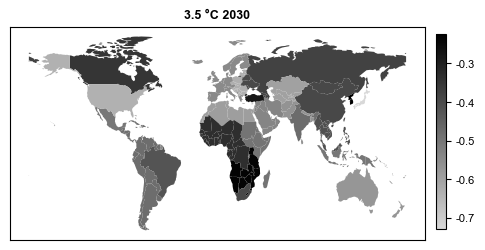

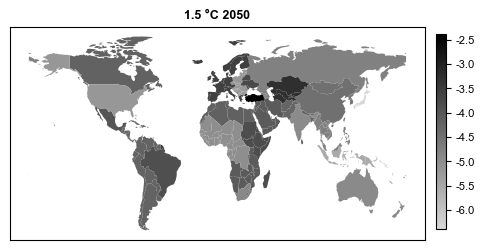

In [17]:
ammoniaFossilDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('ammonia, BAU')]
ammoniaBaseFossilDF = ammoniaFossilDF[ammoniaFossilDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaFossilDF.merge(ammoniaBaseFossilDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP62030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP62050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP192030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
ammoniaRCP192050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Fossil', ammoniaRCP62030, customFossilMap, '3.5 °C 2030', 'Ammonia')
#plot_world_maps('', ammoniaRCP62050, customFossilMap, '3.5 °C 2050', 'Ammonia')
#plot_world_maps('', ammoniaRCP192030, customFossilMap, '1.5 °C 2030', 'Ammonia')
plot_world_maps('Fossil', ammoniaRCP192050, customFossilMap, '1.5 °C 2050', 'Ammonia')

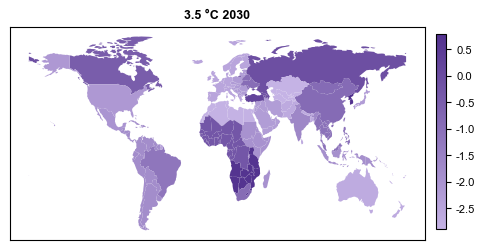

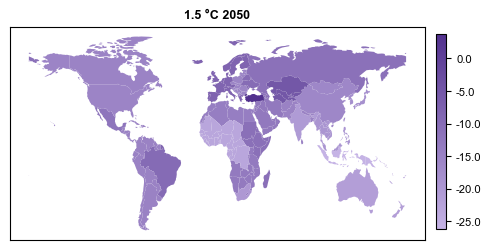

In [18]:
ammoniaBlueDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('ammonia, blue')]
ammoniaBaseBlueDF = ammoniaBlueDF[ammoniaBlueDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaBlueDF.merge(ammoniaBaseBlueDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP62030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP62050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP192030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
ammoniaRCP192050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Blue', ammoniaRCP62030, customBlueMap, '3.5 °C 2030', 'Ammonia')
#plot_world_maps('', ammoniaRCP62050, customBlueMap, '3.5 °C 2050', 'Ammonia')
#plot_world_maps('', ammoniaRCP192030, customBlueMap, '1.5 °C 2030', 'Ammonia')
plot_world_maps('Blue', ammoniaRCP192050, customBlueMap, '1.5 °C 2050', 'Ammonia')

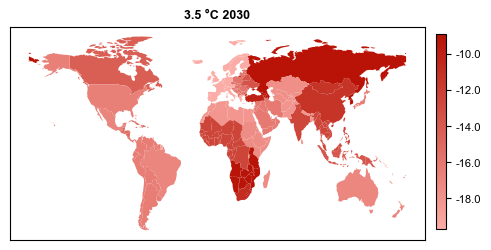

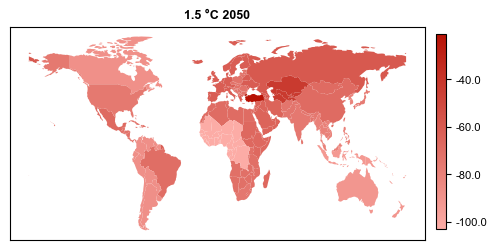

In [19]:
ammoniaSolarDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('solar')]
ammoniaBaseSolarDF = ammoniaSolarDF[ammoniaSolarDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaSolarDF.merge(ammoniaBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP62030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP62050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP192030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
ammoniaRCP192050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Solar', ammoniaRCP62030, customSolarMap, '3.5 °C 2030', 'Ammonia')
#plot_world_maps('', ammoniaRCP62050, customSolarMap, '3.5 °C 2050', 'Ammonia')
#plot_world_maps('', ammoniaRCP192030, customSolarMap, '1.5 °C 2030', 'Ammonia')
plot_world_maps('Solar', ammoniaRCP192050, customSolarMap, '1.5 °C 2050', 'Ammonia')

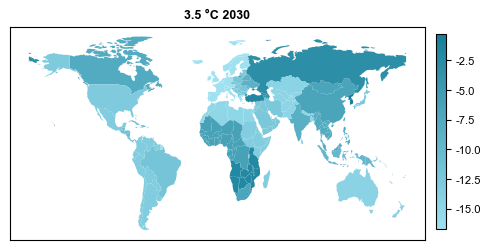

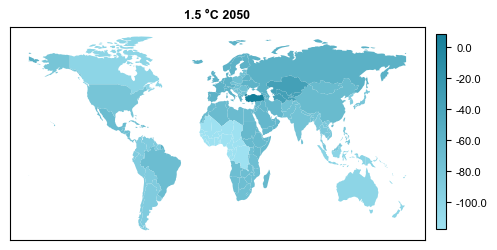

In [20]:
ammoniaWindDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('onshore wind')]
ammoniaBaseWindDF = ammoniaWindDF[ammoniaWindDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaWindDF.merge(ammoniaBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP62030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP62050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP6')]
ammoniaRCP192030 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2030') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
ammoniaRCP192050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Wind', ammoniaRCP62030, customWindMap, '3.5 °C 2030', 'Ammonia')
#plot_world_maps('', ammoniaRCP62050, customWindMap, '3.5 °C 2050', 'Ammonia')
#plot_world_maps('', ammoniaRCP192030, customWindMap, '1.5 °C 2030', 'Ammonia')
plot_world_maps('Wind', ammoniaRCP192050, customWindMap, '1.5 °C 2050', 'Ammonia')

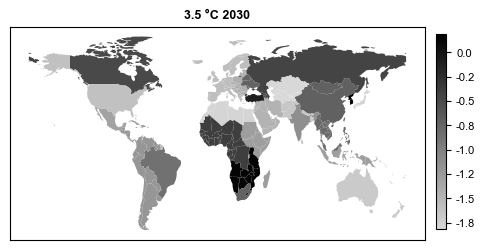

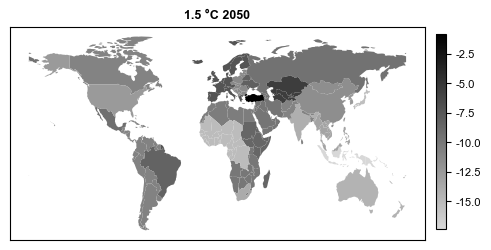

In [21]:
methanolFossilDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol, BAU')]
methanolBaseFossilDF = methanolFossilDF[methanolFossilDF['Database'].str.contains('2020')]
methanolMergedDF = methanolFossilDF.merge(methanolBaseFossilDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = ((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP62030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP62050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP192030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP19')]
methanolRCP192050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Fossil', methanolRCP62030, customFossilMap, '3.5 °C 2030', 'Methanol')
#plot_world_maps('', methanolRCP62050, customFossilMap, '3.5 °C 2050', 'Methanol')
#plot_world_maps('', methanolRCP192030, customFossilMap, '1.5 °C 2030', 'Methanol')
plot_world_maps('Fossil', methanolRCP192050, customFossilMap, '1.5 °C 2050', 'Methanol')

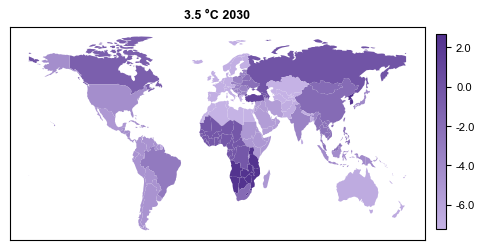

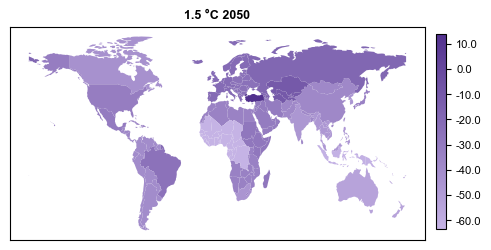

In [22]:
methanolBlueDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol, blue')]
methanolBaseBlueDF = methanolBlueDF[methanolBlueDF['Database'].str.contains('2020')]
methanolMergedDF = methanolBlueDF.merge(methanolBaseBlueDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = ((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP62030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP62050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP192030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP19')]
methanolRCP192050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Blue', methanolRCP62030, customBlueMap, '3.5 °C 2030', 'Methanol')
#plot_world_maps('', methanolRCP62050, customBlueMap, '3.5 °C 2050', 'Methanol')
#plot_world_maps('', methanolRCP192030, customBlueMap, '1.5 °C 2030', 'Methanol')
plot_world_maps('Blue', methanolRCP192050, customBlueMap, '1.5 °C 2050', 'Methanol')

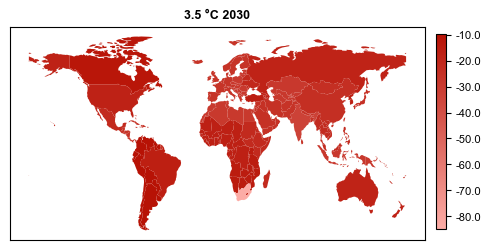

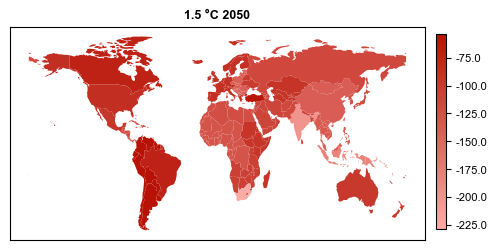

In [23]:
methanolSolarDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseSolarDF = methanolSolarDF[methanolSolarDF['Database'].str.contains('2020')]
methanolMergedDF = methanolSolarDF.merge(methanolBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP62030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP62050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP192030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP19')]
methanolRCP192050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Solar', methanolRCP62030, customSolarMap, '3.5 °C 2030', 'Methanol')
#plot_world_maps('', methanolRCP62050, customSolarMap, '3.5 °C 2050', 'Methanol')
#plot_world_maps('', methanolRCP192030, customSolarMap, '1.5 °C 2030', 'Methanol')
plot_world_maps('Solar', methanolRCP192050, customSolarMap, '1.5 °C 2050', 'Methanol')

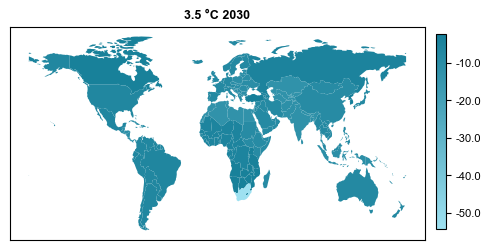

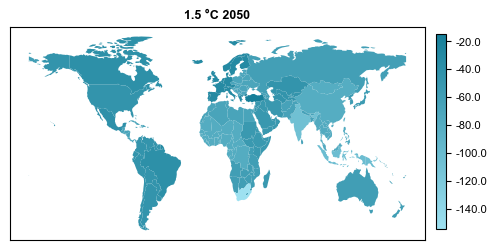

In [24]:
methanolWindDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseWindDF = methanolWindDF[methanolWindDF['Database'].str.contains('2020')]
methanolMergedDF = methanolWindDF.merge(methanolBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP62030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP62050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP6')]
methanolRCP192030 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2030') & methanolMergedDF['RCP'].str.contains('RCP19')]
methanolRCP192050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Wind', methanolRCP62030, customWindMap, '3.5 °C 2030', 'Methanol')
#plot_world_maps('', methanolRCP62050, customWindMap, '3.5 °C 2050', 'Methanol')
#plot_world_maps('', methanolRCP192030, customWindMap, '1.5 °C 2030', 'Methanol')
plot_world_maps('Wind', methanolRCP192050, customWindMap, '1.5 °C 2050', 'Methanol')

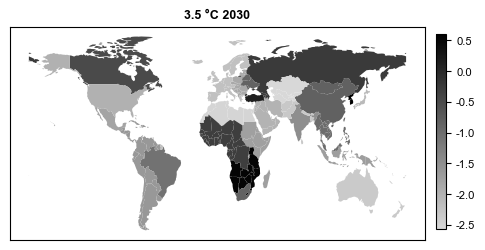

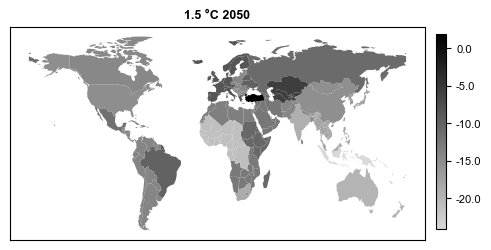

In [25]:
ethyleneFossilDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
ethyleneBaseFossilDF = ethyleneFossilDF[ethyleneFossilDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneFossilDF.merge(ethyleneBaseFossilDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Percent'] = ((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP base']) / ethyleneMergedDF['GWP base']) * 100
ethyleneMergedDF = ethyleneMergedDF[~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneMergedDF.reset_index(drop = True)
ethyleneRCP62030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP62050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP192030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
ethyleneRCP192050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Fossil', ethyleneRCP62030, customFossilMap, '3.5 °C 2030', 'Ethylene')
#plot_world_maps('', ethyleneRCP62050, customFossilMap, '3.5 °C 2050', 'Ethylene')
#plot_world_maps('', ethyleneRCP192030, customFossilMap, '1.5 °C 2030', 'Ethylene')
plot_world_maps('Fossil', ethyleneRCP192050, customFossilMap, '1.5 °C 2050', 'Ethylene')

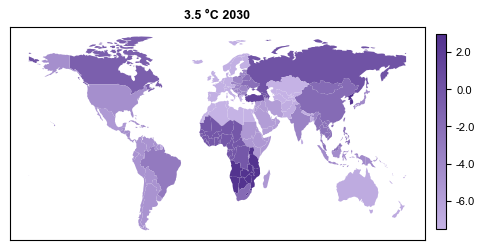

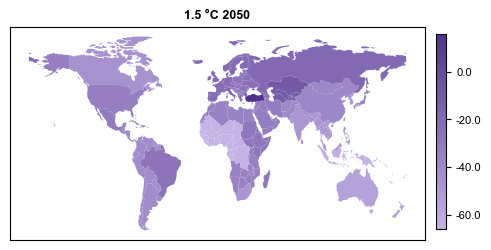

In [26]:
ethyleneBlueDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
ethyleneBaseBlueDF = ethyleneBlueDF[ethyleneBlueDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneBlueDF.merge(ethyleneBaseBlueDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Percent'] = ((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP base']) / ethyleneMergedDF['GWP base']) * 100
ethyleneMergedDF = ethyleneMergedDF[~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneMergedDF.reset_index(drop = True)
ethyleneRCP62030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP62050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP192030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
ethyleneRCP192050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Blue', ethyleneRCP62030, customBlueMap, '3.5 °C 2030', 'Ethylene')
#plot_world_maps('', ethyleneRCP62050, customBlueMap, '3.5 °C 2050', 'Ethylene')
#plot_world_maps('', ethyleneRCP192030, customBlueMap, '1.5 °C 2030', 'Ethylene')
plot_world_maps('Blue', ethyleneRCP192050, customBlueMap, '1.5 °C 2050', 'Ethylene')

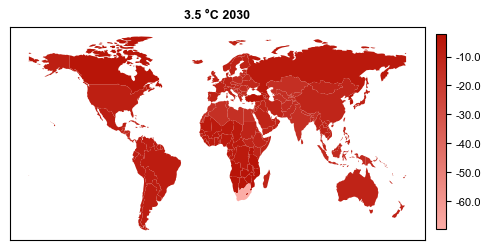

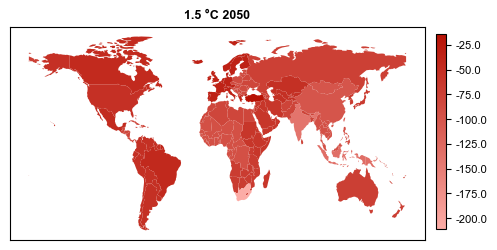

In [27]:
ethyleneSolarDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneBaseSolarDF = ethyleneSolarDF[ethyleneSolarDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneSolarDF.merge(ethyleneBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Percent'] = -((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP base']) / ethyleneMergedDF['GWP base']) * 100
ethyleneMergedDF = ethyleneMergedDF[~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneMergedDF.reset_index(drop = True)
ethyleneRCP62030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP62050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP192030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
ethyleneRCP192050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Solar', ethyleneRCP62030, customSolarMap, '3.5 °C 2030', 'Ethylene')
#plot_world_maps('', ethyleneRCP62050, customSolarMap, '3.5 °C 2050', 'Ethylene')
#plot_world_maps('', ethyleneRCP192030, customSolarMap, '1.5 °C 2030', 'Ethylene')
plot_world_maps('Solar', ethyleneRCP192050, customSolarMap, '1.5 °C 2050', 'Ethylene')

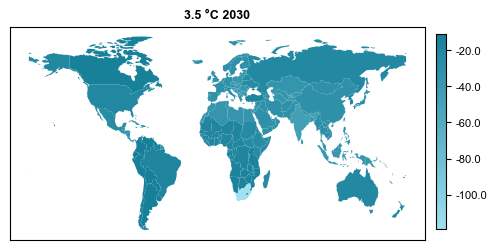

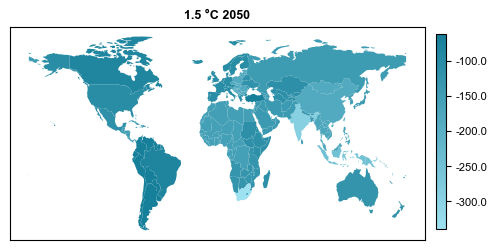

In [28]:
ethyleneWindDF = ethyleneGWPDF[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneBaseWindDF = ethyleneWindDF[ethyleneWindDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneWindDF.merge(ethyleneBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Percent'] = -((ethyleneMergedDF['GWP'] - ethyleneMergedDF['GWP base']) / ethyleneMergedDF['GWP base']) * 100
ethyleneMergedDF = ethyleneMergedDF[~ethyleneMergedDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneMergedDF.reset_index(drop = True)
ethyleneRCP62030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP62050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP6')]
ethyleneRCP192030 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2030') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
ethyleneRCP192050 = ethyleneMergedDF[ethyleneMergedDF['Year'].str.contains('2050') & ethyleneMergedDF['RCP'].str.contains('RCP19')]
plot_world_maps('Wind', ethyleneRCP62030, customWindMap, '3.5 °C 2030', 'Ethylene')
#plot_world_maps('', ethyleneRCP62050, customWindMap, '3.5 °C 2050', 'Ethylene')
#plot_world_maps('', ethyleneRCP192030, customWindMap, '1.5 °C 2030', 'Ethylene')
plot_world_maps('Wind', ethyleneRCP192050, customWindMap, '1.5 °C 2050', 'Ethylene')